# Customer Churn Prediction
### A complete data science case study · Jairus Omondi

**Business understanding → data audit → EDA → preparation → modelling → evaluation → interpretation → delivery → monitoring plan**

This notebook analyses the supplied Telco workbook and develops a reproducible churn classifier. Every result is calculated from the data. The mentor’s sample notebook informs the topic; this implementation uses the actual Excel schema and explicit safeguards against leakage.

The companion interactive demo is in `demo/`. Run this notebook from top to bottom. The model is an educational baseline; evaluation limitations are discussed alongside its results.

## 1. Business understanding

A retention team has limited time and wants to investigate customers whose profiles are associated with churn. Our observational unit is **one customer**. The supplied target, **Churn Value**, is 1 for churned and 0 otherwise.

Questions:
1. How frequent is churn in the supplied snapshot?
2. How do churn rates differ across contract, service and tenure groups?
3. Can a model rank churn-labelled customers above non-churners?
4. At a chosen review threshold, how many churners are caught and how many false alarms occur?

**Success criteria:** outperform a prevalence-based dummy on training cross-validation average precision; report precision, recall, F1, ROC-AUC, average precision and Brier score on a frozen test set; deliver reproducible code and a usable demo. These are academic criteria. Commercial success would require measuring incremental retention benefit and intervention costs.

No future label horizon or feature collection timestamps are documented. Therefore the experiment evaluates historical classification, not verified next-month churn prediction.

In [1]:
from pathlib import Path
import sys, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (average_precision_score, f1_score, precision_score, recall_score,
                             RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay)
from sklearn.calibration import calibration_curve
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))
from churn.pipeline import load_data, preprocessing, metrics, NUMERIC, CATEGORICAL, FEATURES, TARGET
SEED = 42
plt.rcParams.update({'figure.figsize': (9, 4.8), 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})
COLORS = ['#146b85', '#db7b36']
pd.set_option('display.max_columns', 40)

## 2. Acquire and audit the data

The workbook is supplied by the mentor. It contains a telco customer snapshot; the separate PDF is a banking dashboard and uses a different dataset. No transaction dates are available. Raw data and mentor reference files are excluded from the public repository while exact provenance and redistribution terms remain unverified.

We first inspect structure and quality. Row-level examples, IDs and precise locations are omitted from published outputs.

In [2]:
raw = pd.read_excel(ROOT / 'data/raw/Telco_customer_churn.xlsx')
df = load_data(ROOT / 'data/raw/Telco_customer_churn.xlsx')
audit = pd.DataFrame({'dtype': raw.dtypes.astype(str), 'missing_raw': raw.isna().sum(),
                      'unique_values': raw.nunique(), 'missing_after_conversion': df.isna().sum()})
display(audit)
print(f'Customers: {len(df):,} | Columns: {df.shape[1]}')
print('Duplicate customer IDs:', df.CustomerID.duplicated().sum())
print('Duplicate complete rows:', df.duplicated().sum())
print('Constant columns:', df.columns[df.nunique(dropna=False).eq(1)].tolist())
print('Target consistency:', (df['Churn Label'].map({'Yes': 1, 'No': 0}) == df[TARGET]).all())

Customers: 7,043 | Columns: 33
Duplicate customer IDs: 0
Duplicate complete rows: 0
Constant columns: ['Count', 'Country', 'State']
Target consistency: True


,dtype,missing_raw,unique_values,missing_after_conversion
CustomerID,object,0,7043,0
Count,int64,0,1,0
Country,object,0,1,0
State,object,0,1,0
City,object,0,1129,0
Zip Code,int64,0,1652,0
Lat Long,object,0,1652,0
Latitude,float64,0,1652,0
Longitude,float64,0,1651,0
Gender,object,0,2,0


Missing numeric values: {'Tenure Months': 0, 'Monthly Charges': 0, 'Total Charges': 11}
Tenure values among missing Total Charges: {0: 11}


,Tenure Months,Monthly Charges,Total Charges
count,7043.00,7043.00,7032.00
mean,32.37,64.76,2283.30
std,24.56,30.09,2266.77
min,0.00,18.25,18.80
25%,9.00,35.50,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.85,3794.74
max,72.00,118.75,8684.80


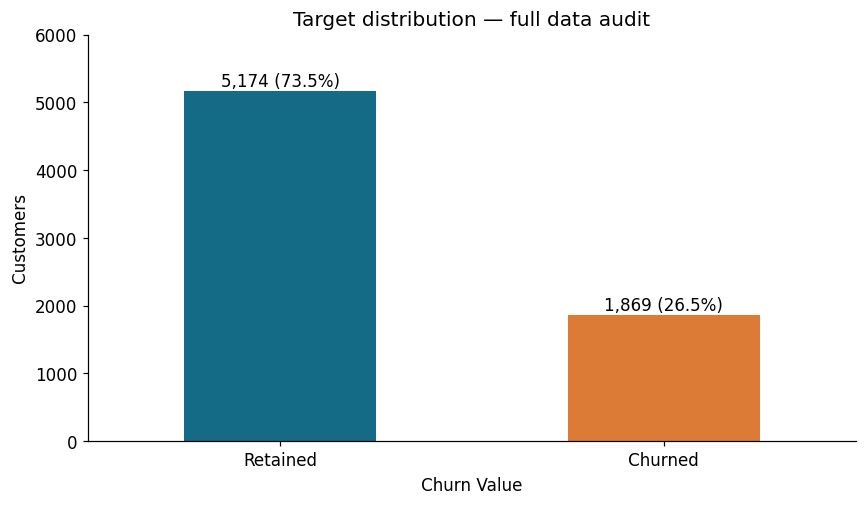

In [3]:
display(df[NUMERIC].describe().round(2))
missing = df[NUMERIC].isna().sum()
print('Missing numeric values:', missing.to_dict())
print('Tenure values among missing Total Charges:',
      df.loc[df['Total Charges'].isna(), 'Tenure Months'].value_counts().to_dict())
label_counts = df[TARGET].value_counts().sort_index()
ax = label_counts.rename(index={0:'Retained', 1:'Churned'}).plot.bar(color=COLORS, rot=0)
ax.set(title='Target distribution — full data audit', ylabel='Customers')
for i, v in enumerate(label_counts): ax.text(i, v+60, f'{v:,} ({v/len(df):.1%})', ha='center')
plt.ylim(0, label_counts.max()*1.16); plt.show()

**Audit interpretation.** There are 7,043 unique customers, with 1,869 churn labels (26.54%). A model that always predicts retention could reach about 73.46% accuracy, so accuracy alone is a weak criterion. Eleven Total Charges entries become missing after blank strings are converted to numbers. They are zero-tenure customers, which we retain and impute within training folds.

Churn Reason is missing for retained customers by design; it is not an ordinary missing predictor. Churn Label duplicates the target, and Churn Score is an existing score with unverified derivation. All three are excluded. CLTV is excluded because its calculation and availability timing are unverified. Constant fields, IDs and geography are also omitted. Gender and Senior Citizen are reserved for descriptive subgroup evaluation.

## 3. Split before exploratory modelling

Use stratified 60% training / 20% validation / 20% test partitions. Stratification preserves approximate churn prevalence. All exploratory feature analysis below uses the training split. Cross-validation chooses the model within training; validation chooses the threshold; the test set assesses the frozen choice.

A random split is necessary with this snapshot but does not establish future performance. A real deployment needs a later dated cohort.

In [4]:
train_val, test = train_test_split(df, test_size=0.2, stratify=df[TARGET], random_state=SEED)
train, val = train_test_split(train_val, test_size=0.25, stratify=train_val[TARGET], random_state=SEED)
assert set(train.CustomerID).isdisjoint(val.CustomerID)
assert set(train.CustomerID).isdisjoint(test.CustomerID)
assert set(val.CustomerID).isdisjoint(test.CustomerID)
display(pd.DataFrame([{'split': name, 'customers':len(part), 'churn_rate':part[TARGET].mean()}
                     for name,part in [('train',train), ('validation',val), ('test',test)]]))

,split,customers,churn_rate
0,train,4225,0.265325
1,validation,1409,0.265436
2,test,1409,0.265436


## 4. Exploratory data analysis
### 4.1 Numeric distributions and unusual values

Inspect tenure, monthly charges and cumulative charges. Differences by churn label can identify associations. High charges are not automatically data errors; no observations are dropped merely because they lie beyond an IQR rule.

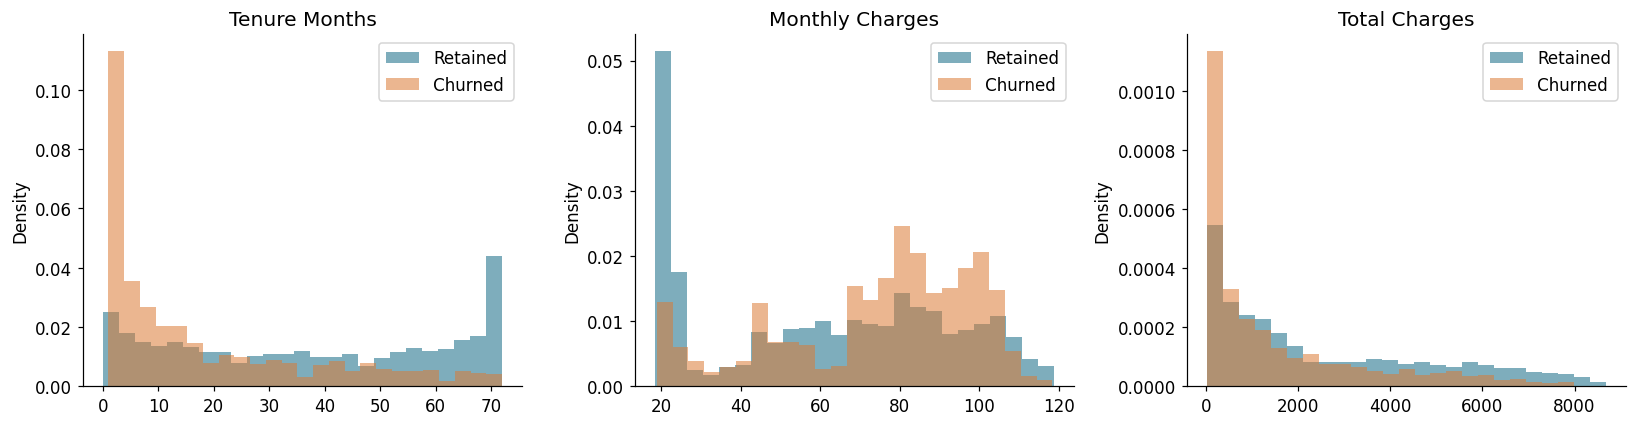

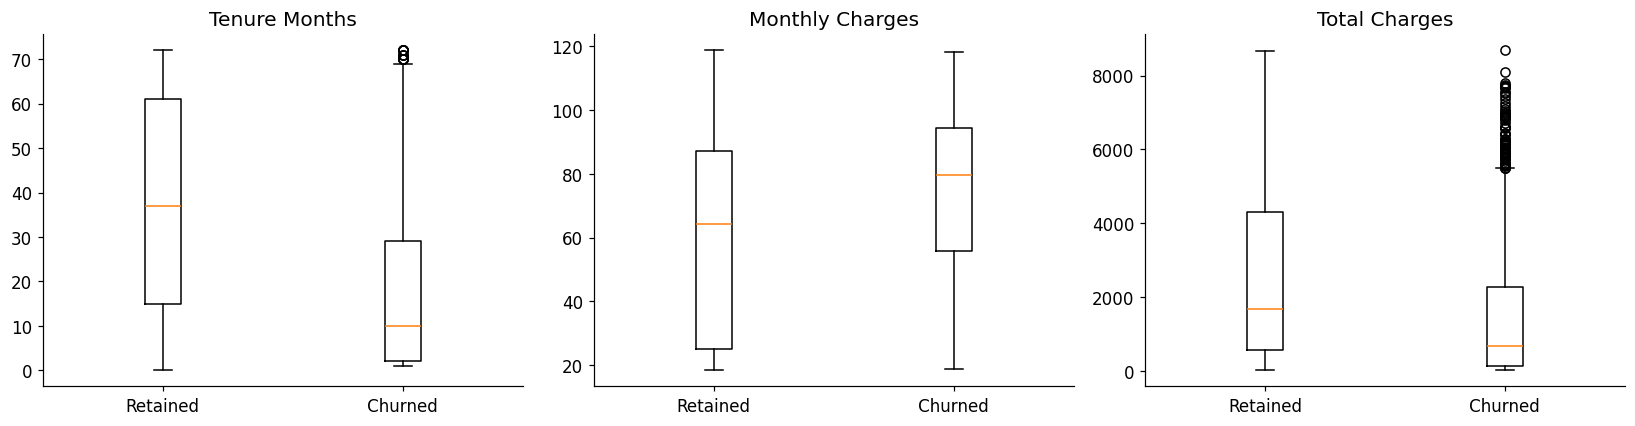

,Tenure Months,Monthly Charges,Total Charges
Churn Value,,,
Retained,37.0,64.375,1677.85
Churned,10.0,79.750,679.30


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, NUMERIC):
    for target, label, color in [(0,'Retained',COLORS[0]), (1,'Churned',COLORS[1])]:
        ax.hist(train.loc[train[TARGET].eq(target), col].dropna(), bins=25,
                alpha=.55, density=True, label=label, color=color)
    ax.set(title=col, ylabel='Density'); ax.legend()
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, NUMERIC):
    ax.boxplot([train.loc[train[TARGET].eq(v),col].dropna() for v in [0,1]],
               tick_labels=['Retained','Churned'], showfliers=True)
    ax.set(title=col)
plt.tight_layout(); plt.show()
display(train.groupby(TARGET)[NUMERIC].median().rename(index={0:'Retained',1:'Churned'}))

**Interpretation.** Compare the displayed medians and distribution overlap. Short tenure and larger monthly bills may be associated with churn; cumulative Total Charges also reflects how long someone stayed. These variables can overlap in what they measure. This does not prove that lowering a bill or extending a contract changes churn.

### 4.2 Contract, service and billing comparisons

Each bar uses churned customers **within that category** divided by all customers in that category. This prevents confusing a category’s share of all churners with its churn rate. The tables retain group size so small segments are visible.

Contract
Internet Service
Payment Method


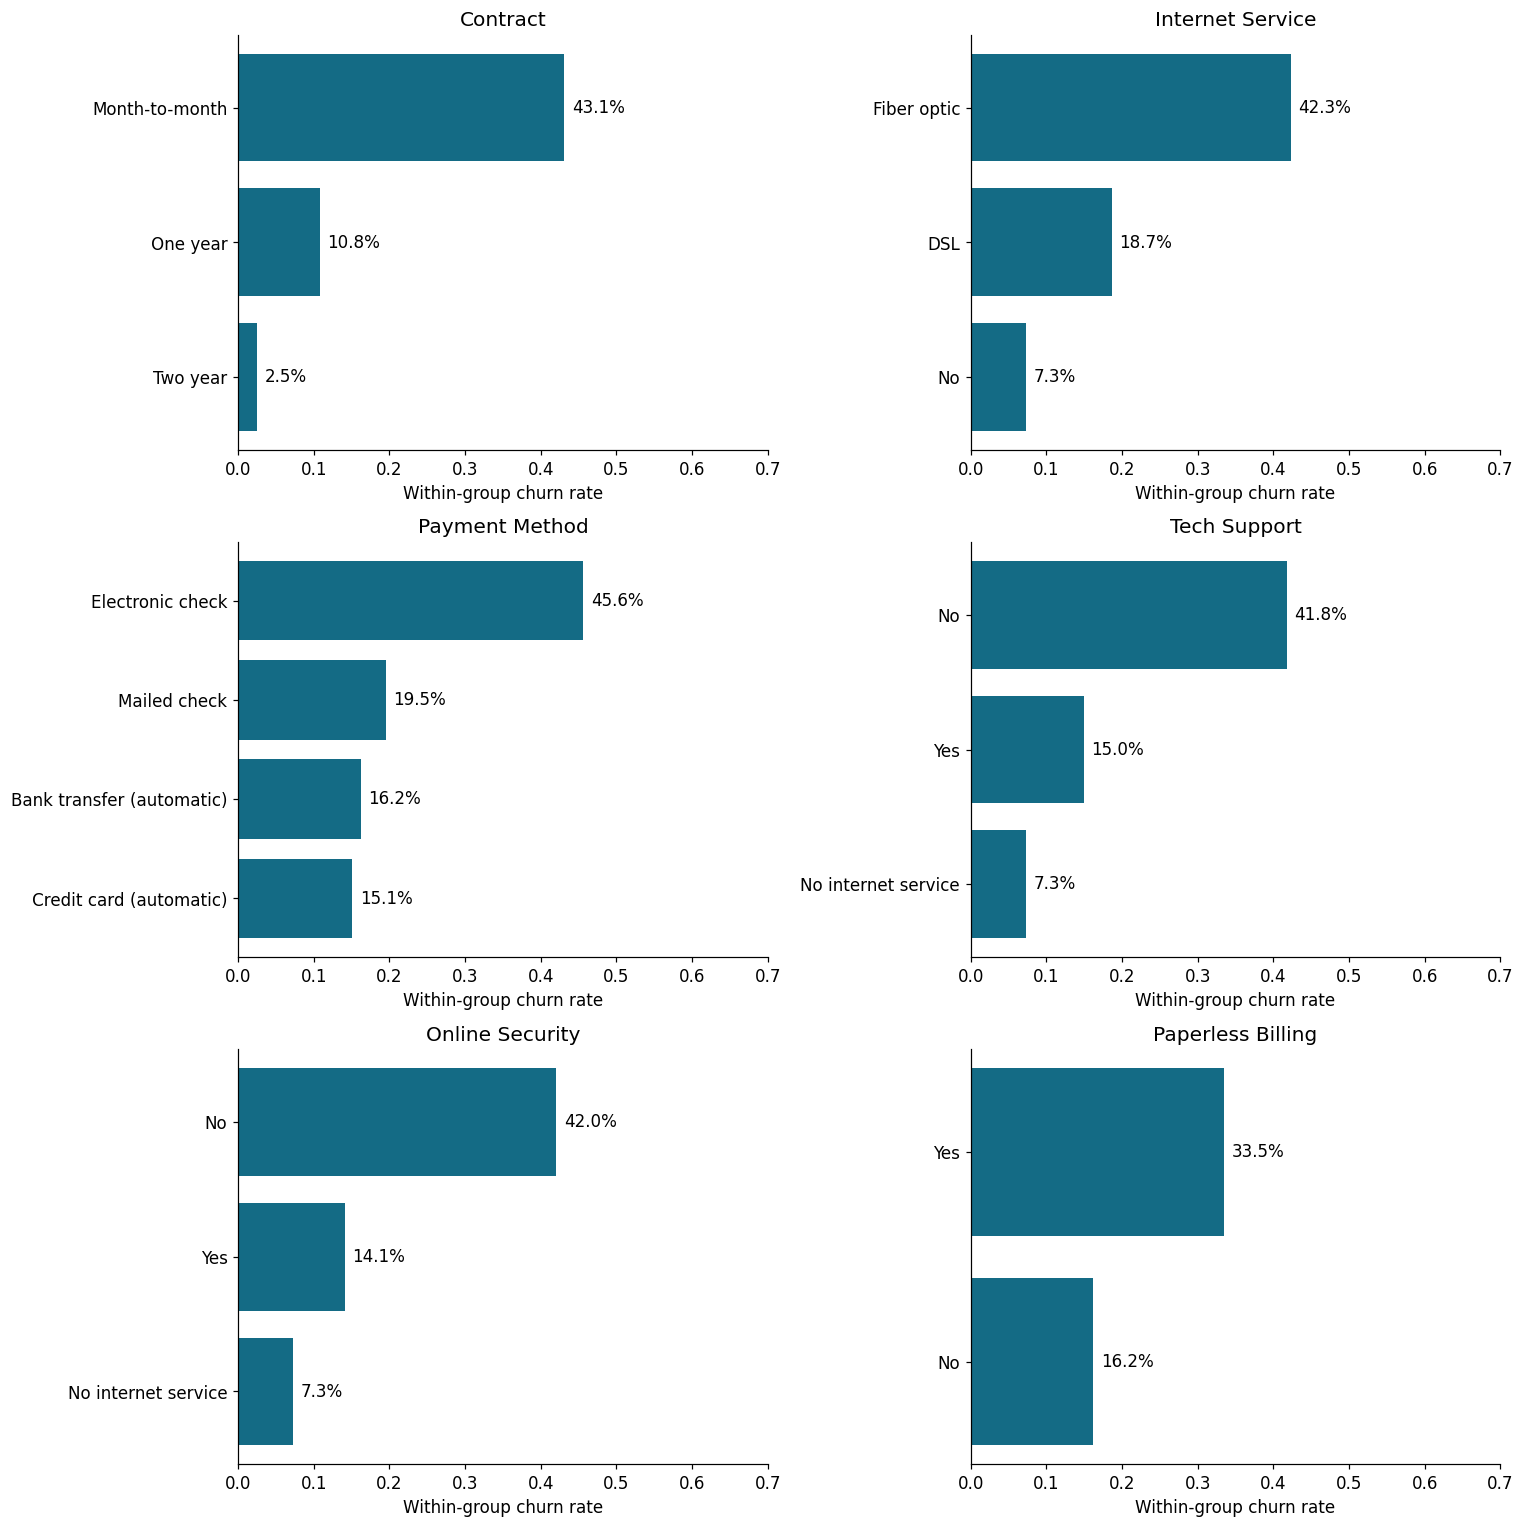

,customers,churned,churn_rate
Contract,,,
Two year,1034,26,0.0251
One year,865,93,0.1075
Month-to-month,2326,1002,0.4308


,customers,churned,churn_rate
Internet Service,,,
No,908,66,0.0727
DSL,1474,275,0.1866
Fiber optic,1843,780,0.4232


,customers,churned,churn_rate
Payment Method,,,
Credit card (automatic),909,137,0.1507
Bank transfer (automatic),926,150,0.1620
Mailed check,980,191,0.1949
Electronic check,1410,643,0.4560


In [6]:
dimensions = ['Contract','Internet Service','Payment Method','Tech Support','Online Security','Paperless Billing']
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
segment_tables = {}
for ax, col in zip(axes.ravel(), dimensions):
    table = train.groupby(col)[TARGET].agg(customers='size', churned='sum', churn_rate='mean')
    table = table.sort_values('churn_rate')
    segment_tables[col] = table
    ax.barh(table.index, table.churn_rate, color=COLORS[0])
    ax.set(title=col, xlabel='Within-group churn rate', xlim=(0,0.7))
    for i,row in enumerate(table.itertuples()):
        ax.text(row.churn_rate+.01,i,f'{row.churn_rate:.1%}',va='center')
plt.tight_layout(); plt.show()
for name in ['Contract','Internet Service','Payment Method']:
    print(name); display(segment_tables[name].round(4))

### 4.3 Tenure cohorts and numeric relationships

Tenure bands are descriptive, fixed in advance. They are not a calendar time series. Numeric correlations show linear relationships only; ordinal numbers should not be invented for nominal categories just to draw a correlation heatmap.

,customers,churn_rate
Tenure band,,
0–12,1318,0.472686
13–24,629,0.292528
25–48,940,0.197872
49–72,1338,0.095665


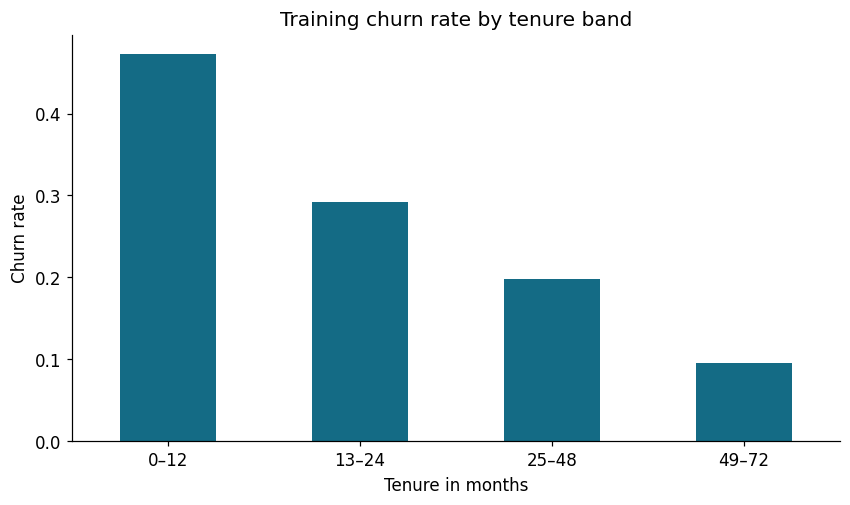

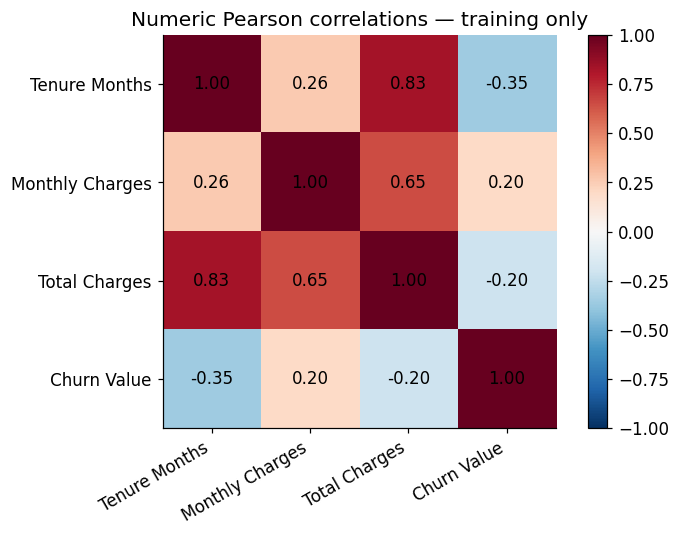

In [7]:
eda = train.copy()
eda['Tenure band'] = pd.cut(eda['Tenure Months'], bins=[-1,12,24,48,72],
                             labels=['0–12','13–24','25–48','49–72'])
tenure_table = eda.groupby('Tenure band', observed=True)[TARGET].agg(customers='size',churn_rate='mean')
display(tenure_table)
ax=tenure_table.churn_rate.plot.bar(color=COLORS[0],rot=0)
ax.set(title='Training churn rate by tenure band',ylabel='Churn rate',xlabel='Tenure in months');plt.show()
corr=train[NUMERIC+[TARGET]].corr()
fig,ax=plt.subplots(figsize=(7,5));im=ax.imshow(corr,vmin=-1,vmax=1,cmap='RdBu_r')
ax.set_xticks(range(len(corr)),corr.columns,rotation=30,ha='right')
ax.set_yticks(range(len(corr)),corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)): ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center')
fig.colorbar(im,ax=ax);ax.set_title('Numeric Pearson correlations — training only');plt.tight_layout();plt.show()

### 4.4 EDA conclusions

Use the generated tables to prioritise contract, tenure and service groups for further investigation. Counts show business scale; rates show relative concentration. Monthly charges can provide a billing exposure proxy, but the file cannot establish realized lost revenue, sales growth, purchase frequency or engagement trends.

**Business hypothesis:** investigate onboarding and service experience for shorter-tenure customers and high-churn service/contract groups, then test interventions with randomized or otherwise credible evaluation. Observational analysis cannot identify which offer will work.

## 5. Data preparation and feature contract

We use 17 explicitly allowed features. Numeric missing values receive training-fold medians and missing indicators, followed by standard scaling. Categorical missing values receive the most frequent training-fold category and one-hot encoding. Unknown categories at inference are ignored rather than causing a failure.

Preprocessing remains inside each model pipeline: every fold learns its own imputation and encoding. No synthetic oversampling is used in this baseline. Class imbalance is addressed through evaluation and threshold choice. Additional feature engineering should be tested on training data before evaluating a new, independently held-out cohort.

In [8]:
display(pd.DataFrame({'feature':FEATURES,'type':['numeric']*len(NUMERIC)+['categorical']*len(CATEGORICAL)}))
forbidden={'Churn Value','Churn Label','Churn Reason','Churn Score','CLTV','CustomerID'}
assert forbidden.isdisjoint(FEATURES)
preprocessor = preprocessing()
print(preprocessor)

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(add_indicator=True,
                                                                strategy='median')),
                                                 ('scale', StandardScaler())]),
                                 ['Tenure Months', 'Monthly Charges',
                                  'Total Charges']),
                                ('categorical',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encode',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Partner', 'Dependents', 'Phone Service',
          

,feature,type
0,Tenure Months,numeric
1,Monthly Charges,numeric
2,Total Charges,numeric
3,Partner,categorical
4,Dependents,categorical
5,Phone Service,categorical
6,Multiple Lines,categorical
7,Internet Service,categorical
8,Online Security,categorical
9,Online Backup,categorical


## 6. Model development and selection

A prevalence-based dummy is the baseline. Logistic regression offers a simple linear model; random forest and gradient boosting capture nonlinear relationships. Fixed modest configurations keep this first experiment reproducible. Hyperparameter search is not performed here.

Choose by five-fold training **average precision** (a precision-recall summary). This emphasizes the positive class. Fold standard deviation describes variation across these folds, not a formal confidence interval.

In [9]:
candidates = {
    'dummy': DummyClassifier(strategy='prior'),
    'logistic': LogisticRegression(max_iter=2000,C=1),
    'random_forest': RandomForestClassifier(n_estimators=200,max_depth=8,min_samples_leaf=10,
                                            n_jobs=2,random_state=SEED),
    'gradient_boosting': GradientBoostingClassifier(n_estimators=100,max_depth=2,random_state=SEED)
}
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=SEED)
comparison_rows=[]; fitted={}
for name, estimator in candidates.items():
    pipe=Pipeline([('preprocess',preprocessing()),('model',estimator)])
    scores=cross_val_score(pipe,train[FEATURES],train[TARGET],cv=cv,scoring='average_precision')
    comparison_rows.append({'model':name,'cv_average_precision':scores.mean(),'cv_std':scores.std()})
    pipe.fit(train[FEATURES],train[TARGET]); fitted[name]=pipe
comparison=pd.DataFrame(comparison_rows).sort_values('cv_average_precision',ascending=False)
display(comparison.round(4))
selected=comparison.iloc[0]['model']; model=fitted[selected]
print('Selected:',selected)

Selected: gradient_boosting


,model,cv_average_precision,cv_std
3,gradient_boosting,0.6950,0.0204
2,random_forest,0.6933,0.0183
1,logistic,0.6883,0.0234
0,dummy,0.2653,0.0005


## 7. Threshold selection on validation data

Ranking and deciding whom to flag are different tasks. Lower thresholds generally flag more customers and increase recall, often lowering precision. We maximize validation F1 as a transparent academic objective because real contact costs, offer costs, capacity and intervention benefits are unknown. This is not an economically optimized threshold.

Frozen threshold: 0.31


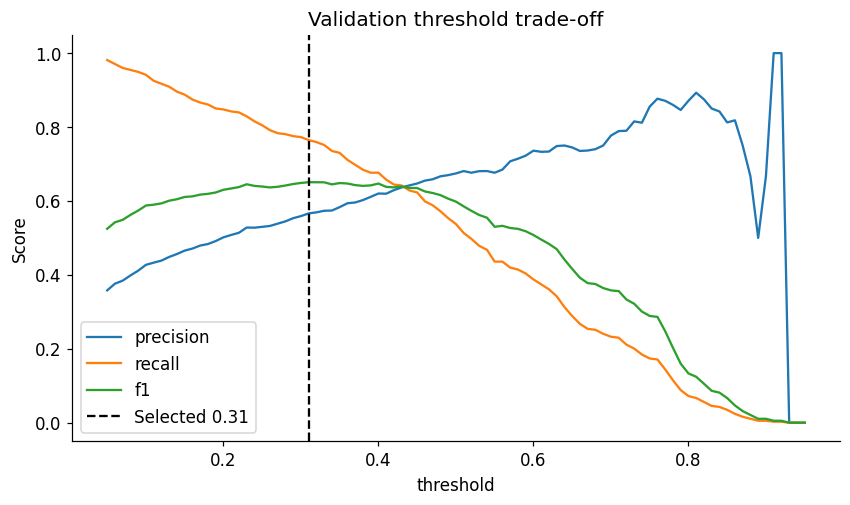

In [10]:
validation_probability=model.predict_proba(val[FEATURES])[:,1]
thresholds=np.arange(.05,.96,.01)
threshold_table=pd.DataFrame([{'threshold':t,
    'precision':precision_score(val[TARGET],validation_probability>=t,zero_division=0),
    'recall':recall_score(val[TARGET],validation_probability>=t),
    'f1':f1_score(val[TARGET],validation_probability>=t)} for t in thresholds])
threshold=float(threshold_table.loc[threshold_table.f1.idxmax(),'threshold'])
ax=threshold_table.plot(x='threshold',y=['precision','recall','f1'])
ax.axvline(threshold,linestyle='--',color='black',label=f'Selected {threshold:.2f}')
ax.set(ylabel='Score',title='Validation threshold trade-off');ax.legend();plt.show()
print(f'Frozen threshold: {threshold:.2f}')

## 8. Final held-out evaluation

The model and threshold are now frozen. We keep the training-fitted model rather than refitting on validation data after threshold selection. Report the test results once. Re-running this fixed notebook reproduces the experiment; repeatedly changing choices based on its test results would turn this test set into development data.

,Test score
average_precision,0.6698
roc_auc,0.8522
accuracy,0.7686
precision,0.5469
recall,0.7487
f1,0.6321
brier,0.1342


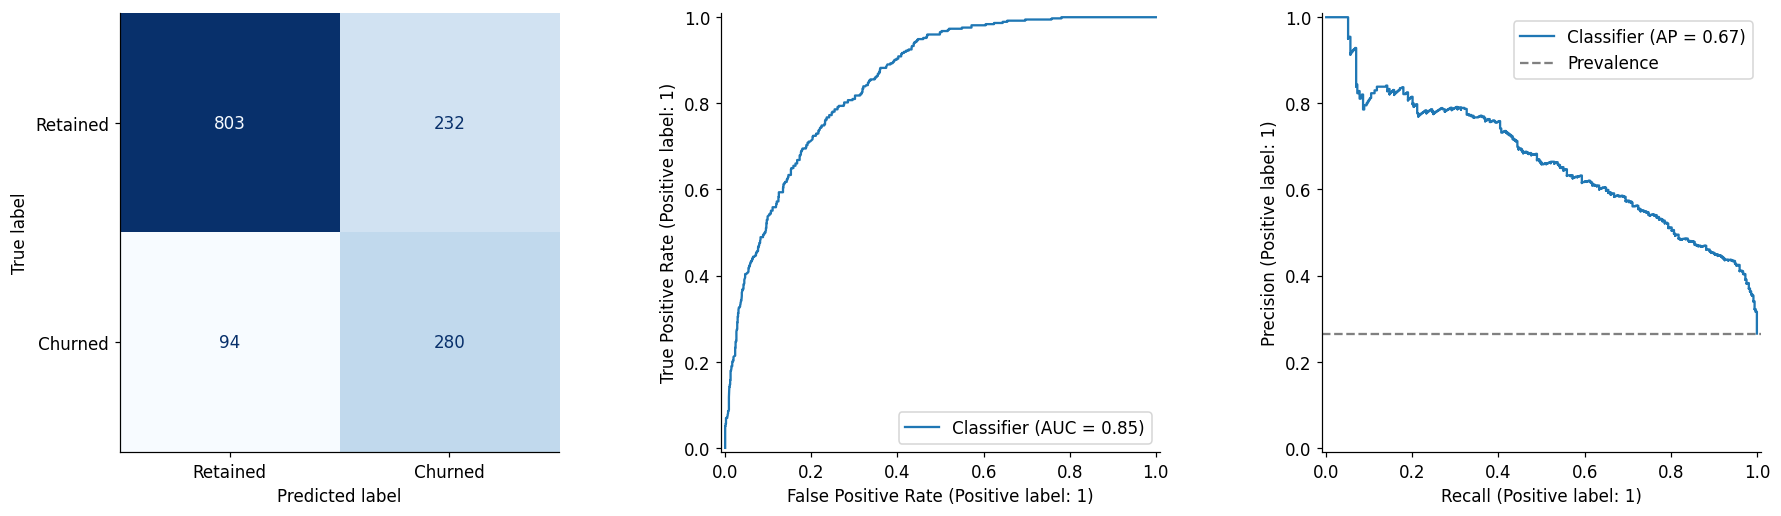

In [11]:
test_probability=model.predict_proba(test[FEATURES])[:,1]
test_metrics=metrics(test[TARGET],test_probability,threshold)
display(pd.Series({k:v for k,v in test_metrics.items() if k!='confusion_matrix'},name='Test score').to_frame().round(4))
fig,axes=plt.subplots(1,3,figsize=(17,4.8))
ConfusionMatrixDisplay.from_predictions(test[TARGET],test_probability>=threshold,
    display_labels=['Retained','Churned'],ax=axes[0],colorbar=False,cmap='Blues')
RocCurveDisplay.from_predictions(test[TARGET],test_probability,ax=axes[1])
PrecisionRecallDisplay.from_predictions(test[TARGET],test_probability,ax=axes[2])
axes[2].axhline(test[TARGET].mean(),color='gray',linestyle='--',label='Prevalence');axes[2].legend()
plt.tight_layout();plt.show()

**Interpretation.** At threshold 0.31, the frozen model identifies 280 of 374 churners (74.9% recall). It also flags 232 retained customers, giving 54.7% precision. Its test ROC-AUC is approximately 0.852 and average precision approximately 0.670. These results demonstrate useful ranking on this split, with a substantial false-positive workload. A retention team needs an explicit capacity and cost model to choose an operational threshold.

### 8.1 Probability reliability and subgroup diagnostics

A probability score should ideally match observed frequency. The reliability diagram is a diagnostic, not a calibration correction. It does not change the frozen model. Subgroup precision and recall are descriptive; sample sizes and uncertainty matter, and excluding demographics does not eliminate proxies.

Gender
Senior Citizen


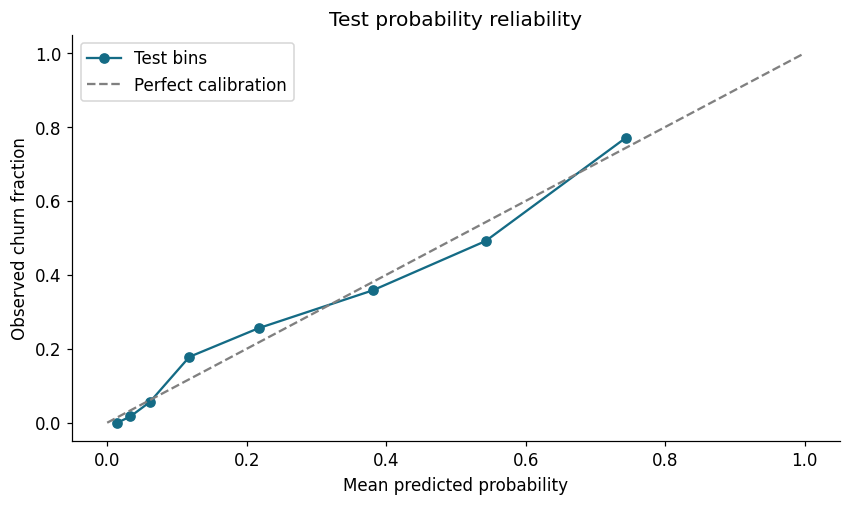

,group,customers,actual_churners,precision,recall
0,Female,687,193,0.5785,0.7254
1,Male,722,181,0.5185,0.7735


,group,customers,actual_churners,precision,recall
0,No,1187,276,0.5223,0.7210
1,Yes,222,98,0.6183,0.8265


In [12]:
fraction_positive, mean_predicted=calibration_curve(test[TARGET],test_probability,n_bins=8,strategy='quantile')
plt.plot(mean_predicted,fraction_positive,'o-',color=COLORS[0],label='Test bins')
plt.plot([0,1],[0,1],'--',color='gray',label='Perfect calibration')
plt.xlabel('Mean predicted probability');plt.ylabel('Observed churn fraction');plt.title('Test probability reliability');plt.legend();plt.show()
for column in ['Gender','Senior Citizen']:
    rows=[]
    for group, part in test.groupby(column):
        prob=model.predict_proba(part[FEATURES])[:,1]
        rows.append({'group':group,'customers':len(part),'actual_churners':int(part[TARGET].sum()),
                     'precision':precision_score(part[TARGET],prob>=threshold,zero_division=0),
                     'recall':recall_score(part[TARGET],prob>=threshold,zero_division=0)})
    print(column);display(pd.DataFrame(rows).round(4))

## 9. Explain model behaviour

Permutation importance shuffles one original feature at a time and measures the loss in validation average precision. Validation data is used here to avoid using test importance to guide development. Correlated variables can share importance. These results explain predictive reliance, not causal effects.

,feature,importance,std
0,Tenure Months,0.0853,0.0079
14,Contract,0.0746,0.0108
4,Dependents,0.0649,0.0167
2,Total Charges,0.0559,0.0142
7,Internet Service,0.0435,0.0065
1,Monthly Charges,0.0271,0.0076
8,Online Security,0.0210,0.0050
11,Tech Support,0.0132,0.0055
16,Payment Method,0.0110,0.0051
15,Paperless Billing,0.0040,0.0047


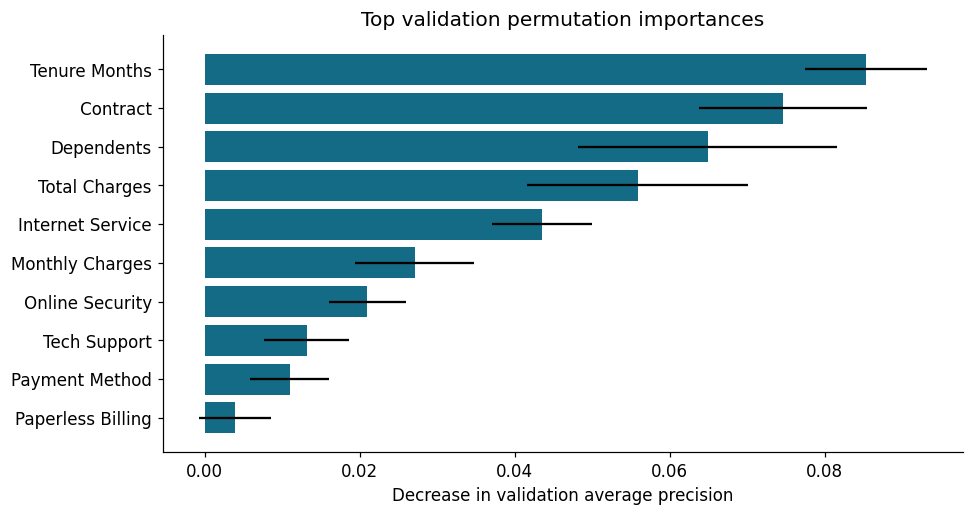

In [13]:
importance=permutation_importance(model,val[FEATURES],val[TARGET],scoring='average_precision',
                                 n_repeats=5,random_state=SEED)
importance_table=pd.DataFrame({'feature':FEATURES,'importance':importance.importances_mean,
                               'std':importance.importances_std}).sort_values('importance',ascending=False)
display(importance_table.round(4))
plot=importance_table.head(10).sort_values('importance')
plt.barh(plot.feature,plot.importance,xerr=plot['std'],color=COLORS[0])
plt.xlabel('Decrease in validation average precision');plt.title('Top validation permutation importances');plt.tight_layout();plt.show()

## 10. Delivery and reproducibility

The CLI (`python -m churn.pipeline`) exports the trained pipeline and experiment reports. The browser demo exports that same gradient boosting model and its preprocessing, then evaluates it locally. A 100-profile parity test checks JavaScript predictions against Python. The Streamlit application is also available for local exploration and CSV batch scoring.

The public repository contains aggregate reports and model code; raw workbook, customer IDs and row-level prediction files remain excluded. Never load an untrusted joblib file.

### Monitoring plan for a future operational system
- Validate a documented prediction horizon and decision-time features on later cohorts.
- Monitor missingness, categories, score distributions and changes in customer mix.
- Evaluate delayed churn outcomes, calibration, ranking, subgroup errors and actual retention benefit.
- Review contact capacity and offer costs; use controlled experiments to estimate incremental benefit.
- Version data, model and threshold, with an approval and rollback process.

These are future operational requirements, not services implemented by this notebook.

## 11. Conclusions and next experiments

The baseline achieves useful discrimination on the supplied historical snapshot. Contract, tenure and service characteristics support investigation, while false positives show why a prediction is only one part of a retention decision.

Limitations: unknown future horizon and feature timing; a random rather than temporal holdout; unverified dataset provenance; no intervention outcomes; no financial optimization; no confidence intervals for the main metrics; subgroup diagnostics do not establish fairness.

Next work: review EDA and error trade-offs together, establish a realistic contact budget, run limited training-only tuning and calibration, and seek dated outcomes before claiming future performance. Any further model selection after seeing these test results requires a fresh final evaluation cohort.

**Learning checkpoint:** explain how a classifier can accurately identify likely churners while a retention campaign still loses money.